In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [31]:
df = pd.read_csv('placement.csv')
df.sample(5)

,cgpa,placement_exam_marks,placed
997,4.89,34.0,0
691,7.32,14.0,0
120,6.99,46.0,1
180,7.18,29.0,0
154,7.57,54.0,1


<Axes: xlabel='placement_exam_marks', ylabel='Probability'>

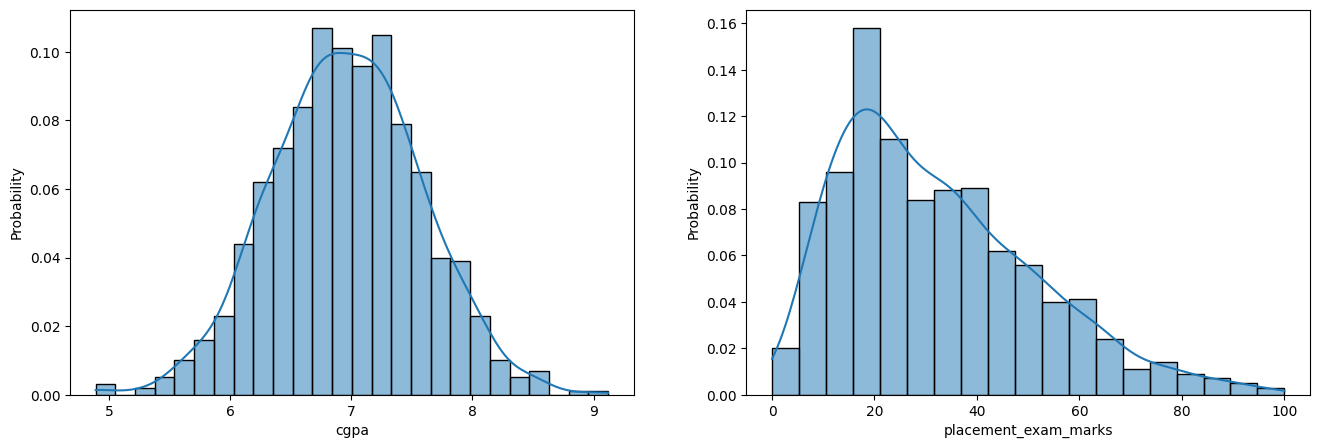

In [32]:
plt.figure(figsize=(16,5))
plt.subplot(1,2,1)
sns.histplot(df['cgpa'],kde=True,stat='probability')

plt.subplot(1,2,2,)
sns.histplot(df['placement_exam_marks'],kde=True,stat='probability')


In [33]:
df['placement_exam_marks'].describe()

count    1000.000000
mean       32.225000
std        19.130822
min         0.000000
25%        17.000000
50%        28.000000
75%        44.000000
max       100.000000
Name: placement_exam_marks, dtype: float64

<Axes: xlabel='placement_exam_marks'>

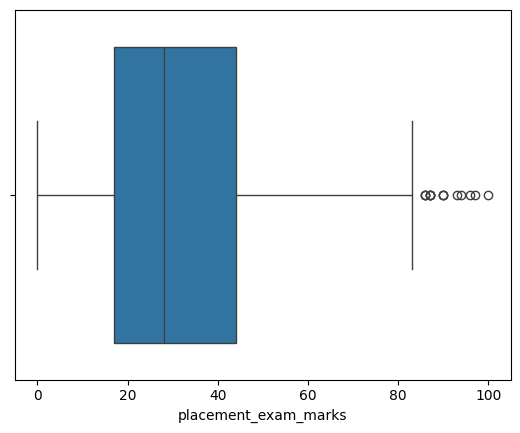

In [34]:
sns.boxplot(x=df['placement_exam_marks'])

In [35]:
percentile25 = df['placement_exam_marks'].quantile(0.25)
percentile75 = df['placement_exam_marks'].quantile(0.75)

In [36]:
print(percentile75)
print(percentile25)

44.0
17.0


In [37]:
iqr = percentile75 - percentile25
iqr

np.float64(27.0)

In [41]:
upper_limit = percentile75 + 1.5*iqr
lower_limit = percentile25 - 1.5*iqr

In [42]:
print(upper_limit)
print(lower_limit)

84.5
-23.5


In [43]:
df[df['placement_exam_marks'] > upper_limit]

,cgpa,placement_exam_marks,placed
9,7.75,94.0,1
40,6.60,86.0,1
61,7.51,86.0,0
134,6.33,93.0,0
162,7.80,90.0,0
283,7.09,87.0,0
290,8.38,87.0,0
311,6.97,87.0,1
324,6.64,90.0,0
630,6.56,96.0,1


In [44]:
df[df['placement_exam_marks'] < lower_limit]

,cgpa,placement_exam_marks,placed


In [45]:
### triming
new_df = df[df['placement_exam_marks'] < upper_limit]
new_df.shape

(985, 3)

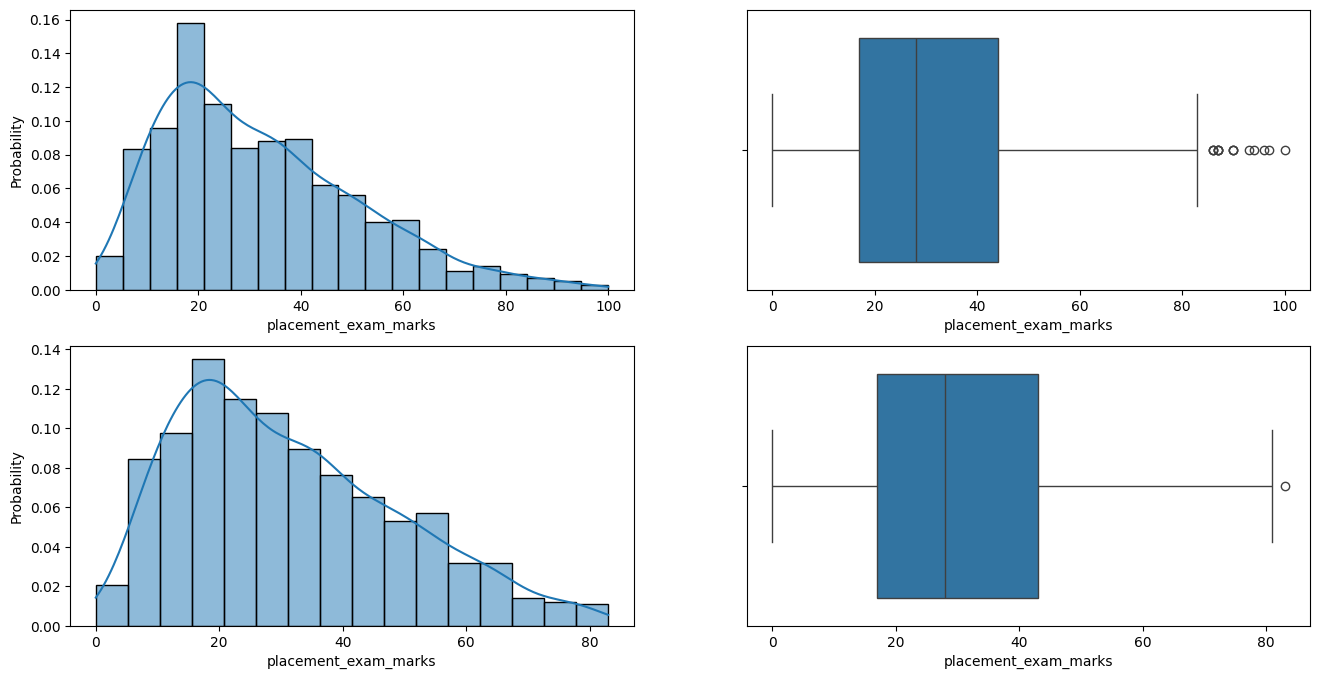

In [48]:
plt.figure(figsize=(16,8))
plt.subplot(2,2,1)
sns.histplot(df['placement_exam_marks'],kde=True,stat='probability')
plt.subplot(2,2,2)
sns.boxplot(x=df['placement_exam_marks'])
plt.subplot(2,2,3)
sns.histplot(new_df['placement_exam_marks'],kde=True,stat='probability')
plt.subplot(2,2,4)
sns.boxplot(x=new_df['placement_exam_marks'])

plt.show()

In [ ]:
### capping
new_df_cap = df.copy()

# np.where(codition,true,false)

new_df_cap['placement_exam_marks'] = np.where(
    new_df_cap['placement_exam_marks'] > upper_limit,
    upper_limit,
    np.where(
        new_df_cap['placement_exam_marks'] < lower_limit,
        lower_limit,
        new_df_cap['placement_exam_marks']
    )
)

In [50]:
new_df_cap.shape

(1000, 3)

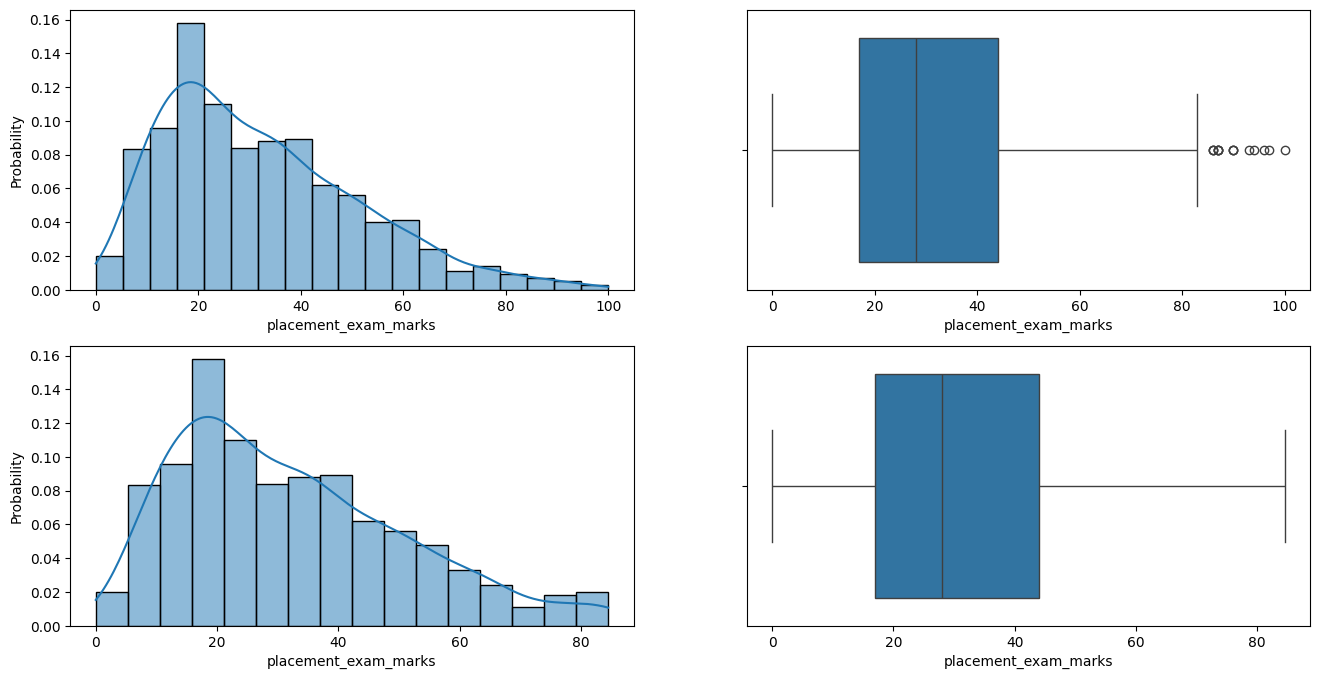

: 

In [ ]:
plt.figure(figsize=(16,8))
plt.subplot(2,2,1)
sns.histplot(df['placement_exam_marks'],kde=True,stat='probability')
plt.subplot(2,2,2)
sns.boxplot(x=df['placement_exam_marks'])
plt.subplot(2,2,3)
sns.histplot(new_df_cap['placement_exam_marks'],kde=True,stat='probability')
plt.subplot(2,2,4)
sns.boxplot(x=new_df_cap['placement_exam_marks'])

plt.show()